# Load Sentinel-3 data from the CDSE STAC catalog

This notebook shows an example how to load Sentinel-3 data from the [CDSE STAC API](https://browser.stac.dataspace.copernicus.eu/?.language=en).

### Setup
In order to run this notebook you may install [`xcube_stac`](https://github.com/xcube-dev/xcube-stac), following the [README](../../README.md).

The data can be accessed via S3, where key and secret can be obtained following the [CDSE access documentation to EO data via S3](https://documentation.dataspace.copernicus.eu/APIs/S3.html#generate-secrets). The store object will receive the key and secret upon initialization, as demonstrated below.

Now, we first import everything we need:

In [1]:
%%time

import xarray as xr
from xcube.core.store import new_data_store, get_data_store_params_schema

CPU times: user 4.34 s, sys: 358 ms, total: 4.7 s
Wall time: 2.76 s


In [2]:
xr.set_options(display_expand_attrs=False)

Next store the credentials in a dictionary. 

In [3]:
credentials = dict(
    key="O0M0CUQIDQO9TDZ4D8NR",
    secret="qPUyXs9G6j8on6MY5KPhQNHuA5uZTqxEscrbBCGx",
)

There are two [data stores](https://xcube.readthedocs.io/en/latest/dataaccess.html#data-store-framework) available for the [CDSE STAC API](https://browser.stac.dataspace.copernicus.eu/?language=en):

- **`stac-cdse-ardc`**: Allows you to open multiple STAC items and assemble them into a 3D spatiotemporal data cube.
- **`stac-cdse`**: Enables you to open individual STAC items.

---
## Data store to access spatiotemporal anaylsis-ready data cubes 

In the following, we will first demonstrate how to use the `stac-cdse-ardc` store. To view the parameters to initialize the data store instance, execute the following cell. 

> **Note:**  
> Access requires your S3 `key` and `secret`.

In [4]:
%%time
store_params = get_data_store_params_schema("stac-cdse-ardc")
store_params

CPU times: user 322 ms, sys: 60.9 ms, total: 383 ms
Wall time: 382 ms


In [5]:
%%time
store = new_data_store("stac-cdse-ardc", **credentials)

CPU times: user 22.7 ms, sys: 4.12 ms, total: 26.8 ms
Wall time: 177 ms


The following cell shows the available data IDs for the analysis-ready datacube mode. The data IDs point to a STAC collections.

In [6]:
%%time
data_ids = store.list_data_ids()
data_ids

CPU times: user 18 μs, sys: 2 μs, total: 20 μs
Wall time: 21.7 μs


['sentinel-2-l2a',
 'sentinel-2-l1c',
 'sentinel-3-syn-2-syn-ntc',
 'sentinel-3-sl-2-lst-ntc']

Below, the parameters for the `open_data` method can be viewed for aspecific data ID.

In [7]:
%%time
open_params = store.get_open_data_params_schema("sentinel-3-syn-2-syn-ntc")
open_params

CPU times: user 7.93 ms, sys: 87 μs, total: 8.01 ms
Wall time: 7.76 ms


The store supports the collection `"sentinel-3-syn-2-syn-ntc"`, from which ARDC can be built as shown in the next cell. 

In [8]:
%%time
ds = store.open_data(
    data_id="sentinel-3-syn-2-syn-ntc",
    bbox=[8, 52, 12, 55],
    time_range=["2020-07-31", "2020-08-01"],
    spatial_res=300 / 111320,  # meter in degree
    crs="EPSG:4326",
    asset_names=["syn_Oa01_reflectance", "syn_Oa02_reflectance"],
)
ds

CPU times: user 15.4 s, sys: 5.64 s, total: 21 s
Wall time: 6min 51s


<xarray.Dataset> Size: 106MB
Dimensions:       (time: 2, lat: 1114, lon: 1485)
Coordinates:
  * time          (time) datetime64[ns] 16B 2020-07-31T10:10:08.191012 2020-0...
  * lat           (lat) float64 9kB 55.0 55.0 55.0 54.99 ... 52.01 52.0 52.0
  * lon           (lon) float64 12kB 8.001 8.004 8.007 8.009 ... 12.0 12.0 12.0
    spatial_ref   int64 8B 0
Data variables:
    SDR_Oa01      (time, lat, lon) float64 26MB dask.array<chunksize=(1, 1114, 1485), meta=np.ndarray>
    SDR_Oa01_err  (time, lat, lon) float64 26MB dask.array<chunksize=(1, 1114, 1485), meta=np.ndarray>
    SDR_Oa02      (time, lat, lon) float64 26MB dask.array<chunksize=(1, 1114, 1485), meta=np.ndarray>
    SDR_Oa02_err  (time, lat, lon) float64 26MB dask.array<chunksize=(1, 1114, 1485), meta=np.ndarray>
Attributes: (3)

/home/konstantin/micromamba/envs/xcube-multistore/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


We can plot the spectral band 0 from the  OLCI Instrument as an example.

CPU times: user 4.04 s, sys: 537 ms, total: 4.58 s
Wall time: 6.94 s


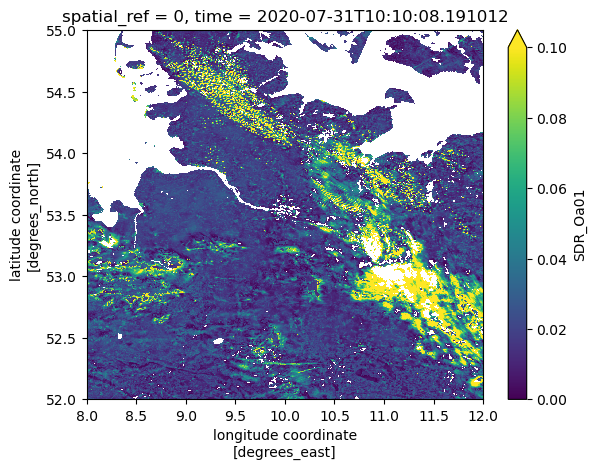

In [9]:
%%time
ds.SDR_Oa01.isel(time=-2).plot(vmin=0.0, vmax=0.1)

Next, we retrieve ARDC from the Sentinel-3 SLSTR Land Surface Temperature collection (`"sentinel-3-sl-2-lst-ntc"`).

In [7]:
%%time
ds = store.open_data(
    data_id="sentinel-3-sl-2-lst-ntc",
    bbox=[8, 52, 12, 55],
    time_range=["2020-07-31", "2020-08-01"],
    spatial_res=300 / 111320,  # meter in degree
    crs="EPSG:4326",
)

CPU times: user 11.3 s, sys: 9.49 s, total: 20.8 s
Wall time: 4min 30s


CPU times: user 1.93 s, sys: 259 ms, total: 2.19 s
Wall time: 868 ms


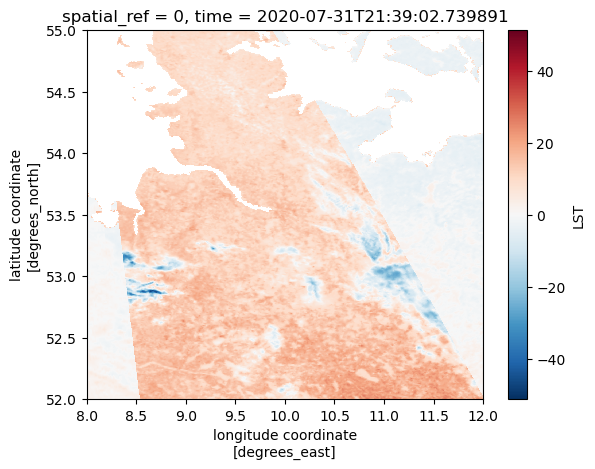

In [9]:
%%time
ds.LST.isel(time=-2).plot()

----
## Data store to access single observations
Now, we initiate the data store to access each STAC item representing one observation tile. 

In [10]:
%%time
store_params = get_data_store_params_schema("stac-cdse")
store_params

CPU times: user 42 μs, sys: 12 μs, total: 54 μs
Wall time: 57.5 μs


To initialize the CDSE STAC data store, execute the following cell.

In [10]:
%%time
store = new_data_store("stac-cdse", **credentials)

CPU times: user 38.7 ms, sys: 7.45 ms, total: 46.2 ms
Wall time: 187 ms


Below, the parameters for the `open_data` method can be viewed.

In [12]:
%%time
open_params = store.get_open_data_params_schema()
open_params

CPU times: user 24 μs, sys: 7 μs, total: 31 μs
Wall time: 33.6 μs


If we specify the data ID, we obtain more precise parameters for opening and accessing that specific dataset.

In [13]:
data_id = (
    "collections/sentinel-3-syn-2-syn-ntc/items/S3B_SY_2_SYN____20250706T233058_"
    "20250706T233358_20250708T043306_0179_108_258_3420_ESA_O_NT_002"
)
store.get_open_data_params_schema(data_id=data_id)

We can now open the data set associated with the data ID. Note that first we do not apply any rectification. Thus the data is shown on the irregular native grid. 

In [14]:
%%time
ds = store.open_data(data_id, apply_rectification=False, add_error_bands=False)
ds

CPU times: user 746 ms, sys: 419 ms, total: 1.16 s
Wall time: 14.8 s


<xarray.Dataset> Size: 2GB
Dimensions:   (y: 4091, x: 4865)
Coordinates:
    lon       (y, x) float64 159MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    lat       (y, x) float64 159MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables: (12/26)
    SDR_S1N   (y, x) float32 80MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_S1O   (y, x) float32 80MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_S2N   (y, x) float32 80MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_S2O   (y, x) float32 80MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_S3N   (y, x) float32 80MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_S3O   (y, x) float32 80MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    ...        ...
    SDR_Oa11  (y, x) float32 80MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_Oa12  (y, x) float32 80MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_Oa16  (y, x) float32 80MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_Oa17  (y, x) float32 80MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_Oa18  (y, x) float32 80MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_Oa21  (y, x) float32 80MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
Attributes: (15)

CPU times: user 1.65 s, sys: 1.16 s, total: 2.81 s
Wall time: 27.9 s


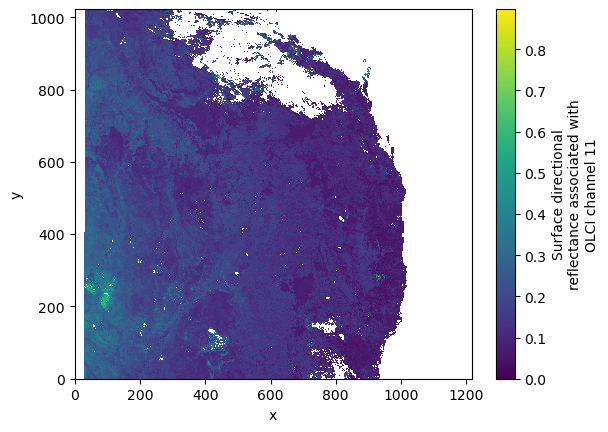

In [15]:
%%time
ds.SDR_Oa11[::4, ::4].plot()

In the next step we show the dataset on a regular grid, where the [xcube's rectification algorithm](https://xcube.readthedocs.io/en/latest/rectify.html) is applied. Note that showing the data on a regular grid is the default. 

In [16]:
%%time
ds = store.open_data(data_id)
ds

CPU times: user 10.4 s, sys: 2.81 s, total: 13.2 s
Wall time: 42 s


<xarray.Dataset> Size: 7GB
Dimensions:       (lon: 6020, lat: 5275)
Coordinates:
  * lon           (lon) float64 48kB 140.9 140.9 140.9 ... 157.0 157.0 157.0
  * lat           (lat) float64 42kB -21.05 -21.06 -21.06 ... -34.52 -34.53
    spatial_ref   int64 8B 0
Data variables: (12/52)
    SDR_S1N       (lat, lon) float32 127MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_S1N_err   (lat, lon) float32 127MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_S1O       (lat, lon) float32 127MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_S1O_err   (lat, lon) float32 127MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_S2N       (lat, lon) float32 127MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_S2N_err   (lat, lon) float32 127MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    ...            ...
    SDR_Oa17      (lat, lon) float32 127MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_Oa17_err  (lat, lon) float32 127MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_Oa18      (lat, lon) float32 127MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_Oa18_err  (lat, lon) float32 127MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_Oa21      (lat, lon) float32 127MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
    SDR_Oa21_err  (lat, lon) float32 127MB dask.array<chunksize=(1023, 1217), meta=np.ndarray>
Attributes: (15)

CPU times: user 1min 7s, sys: 22.3 s, total: 1min 30s
Wall time: 16.7 s


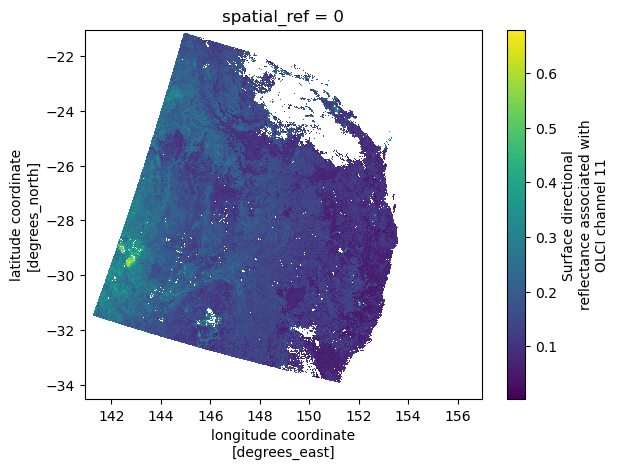

In [17]:
%%time
ds.SDR_Oa11[::4, ::4].plot()

In [21]:
%%time
data_id = "collections/sentinel-3-sl-2-lst-ntc/items/S3B_SL_2_LST____20260217T102917_20260217T103217_20260218T165304_0180_117_008_2520_ESA_O_NT_004"
ds = store.open_data(data_id, apply_rectification=False)
ds

CPU times: user 328 ms, sys: 128 ms, total: 456 ms
Wall time: 2.54 s


<xarray.Dataset> Size: 36MB
Dimensions:  (y: 1200, x: 1500)
Coordinates:
    lat      (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    lon      (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    LST      (y, x) float32 7MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Attributes: (17)

CPU times: user 422 ms, sys: 90.2 ms, total: 512 ms
Wall time: 494 ms


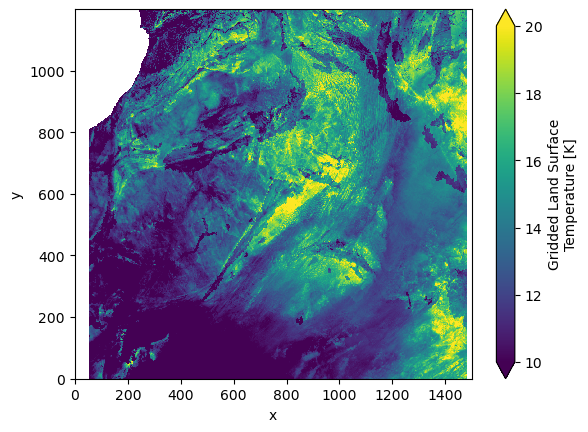

In [22]:
%%time
ds.LST.plot(vmin=10, vmax=20)

In [23]:
%%time
ds = store.open_data(data_id)
ds

CPU times: user 665 ms, sys: 109 ms, total: 774 ms
Wall time: 2.64 s


<xarray.Dataset> Size: 11MB
Dimensions:      (lon: 1751, lat: 1522)
Coordinates:
  * lon          (lon) float64 14kB -14.17 -14.16 -14.15 ... 2.856 2.866 2.876
  * lat          (lat) float64 12kB 31.5 31.5 31.49 31.48 ... 18.18 18.18 18.17
    spatial_ref  int64 8B 0
Data variables:
    LST          (lat, lon) float32 11MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Attributes: (17)

CPU times: user 5.19 s, sys: 463 ms, total: 5.66 s
Wall time: 2.09 s


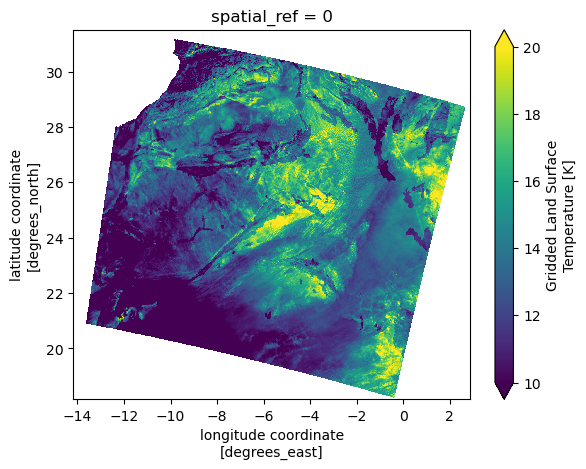

In [24]:
%%time
ds.LST.plot(vmin=10, vmax=20)